In [ ]:
"""
Step 4 of 5 — bootstrap intervals from historical forecast error (Section V-D).

Each institution's signed errors are resampled and mapped back to an implied
outcome, and the three implied outcomes are re-aggregated through the OWAGDP at
each orness level.

SIGN. With e = forecast - actual, the implied outcome is forecast - e, NOT
forecast + e. The manuscript says "add the drawn error to the current forecast";
the arithmetic behind the published numbers subtracts it. Fix the sentence.

RESAMPLE. Two schemes are run, not one:
  independent  each institution drawn separately. This is the published
               specification. It breaks the correlation between institutional
               errors, so the intervals are too NARROW.
  rounds       whole rounds drawn together, keeping the common shock intact.
               This is the defensible specification.
Both are reported so the difference is visible rather than asserted.

A caution the script prints and the paper should repeat: with five rounds there
are five signed errors per institution. Independent draws give at most 5^3 = 125
distinct triples; paired draws give 5. Ten thousand replicates resample a
support that small, so these are not 95% intervals in any coverage sense. Call
them what they are -- the span of the historical error distribution carried
through the operator.

UPLOAD   aggregates.csv       (02_aggregate)
         forecast_errors.csv  (03a_build_errors)
WRITES   boot_full.csv        full scoring window
         boot_excl2021.csv    excluding the 2021 COVID-rebound target
"""
import os
import numpy as np
import pandas as pd

INST = ["IMF", "OECD", "EC"]
SEED, B = 42, 10_000
ALPHAS = [0.2, 0.5, 0.8]        # 0.5 is the level plotted in Figure 3
YEARS = (2026, 2027)
MIN_ROUNDS = 3
COVID_TARGET = 2021
CI = (2.5, 97.5)

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def grab(cols, label):
    def scan():
        for f in sorted(os.listdir(".")):
            if f.lower().endswith(".csv"):
                try:
                    if cols.issubset(pd.read_csv(f, nrows=1).columns):
                        return f
                except Exception:
                    pass
        return None
    f = scan()
    if f is None and IN_COLAB:
        print(f"Upload {label}")
        files.upload()
        f = scan()
    if f is None:
        raise FileNotFoundError(f"no csv here with columns {sorted(cols)} "
                                f"({label}).\nPresent: {sorted(os.listdir('.'))}")
    print(f"{label:<20}{f}")
    return pd.read_csv(f)


agg = grab({"iso", "year", *INST}, "aggregates.csv")
err = grab({"iso", "target", "actual", *INST}, "forecast_errors.csv")
print()


def me_weights(alpha, n=3):
    if abs(alpha - 0.5) < 1e-12:
        return np.full(n, 1.0 / n)

    def orness(h):
        w = h ** np.arange(n)
        w = w / w.sum()
        return ((n - 1 - np.arange(n)) * w).sum() / (n - 1), w

    lo, hi = 1e-9, 1e9
    for _ in range(200):
        h = np.sqrt(lo * hi)
        lo, hi = (h, hi) if orness(h)[0] > alpha else (lo, h)
    return orness(np.sqrt(lo * hi))[1]


W = {a: me_weights(a) for a in ALPHAS}

for k in INST:
    err["s_" + k] = err[k] - err["actual"]


def bootstrap(drop_2021, scheme, seed=SEED):
    rng = np.random.default_rng(seed)
    e = err[err.target != COVID_TARGET] if drop_2021 else err
    rows, support = [], []
    for iso in sorted(agg.iso.unique()):
        h = e[e.iso == iso]
        pools = {k: h["s_" + k].dropna().values for k in INST}
        if any(len(v) < MIN_ROUNDS for v in pools.values()):
            continue
        paired = h.dropna(subset=["s_" + k for k in INST])
        support.append(len(paired) if scheme == "rounds"
                       else np.prod([len(v) for v in pools.values()]))
        for y in YEARS:
            row = agg[(agg.iso == iso) & (agg.year == y)]
            if row.empty:
                continue
            f = row.iloc[0]
            if scheme == "rounds":            # keep the common shock intact
                idx = rng.integers(0, len(paired), B)
                draws = np.column_stack(
                    [f[k] - paired["s_" + k].values[idx] for k in INST])
            else:                              # published specification
                draws = np.column_stack(
                    [f[k] - rng.choice(pools[k], B) for k in INST])
            srt = np.sort(draws, axis=1)[:, ::-1]
            rec = {"iso": iso, "year": y}
            for a in ALPHAS:
                agv = srt @ W[a]
                lo, hi = np.percentile(agv, CI)
                rec[f"lo_{a}"] = lo
                rec[f"hi_{a}"] = hi
                rec[f"med_{a}"] = np.median(agv)
                rec[f"width_{a}"] = hi - lo
            rows.append(rec)
    return pd.DataFrame(rows), int(np.min(support)) if support else 0


results = {}
for drop in (False, True):
    for scheme in ("independent", "rounds"):
        results[(drop, scheme)] = bootstrap(drop, scheme)

# the published pair, written for step 5
results[(False, "independent")][0].round(4).to_csv("boot_full.csv", index=False)
results[(True, "independent")][0].round(4).to_csv("boot_excl2021.csv", index=False)

# ---------------------------------------------------------------- report ----
spread_med = (agg.spread.median() if "spread" in agg.columns else np.nan)
print(f"seed {SEED} | replicates {B} | percentiles {CI}\n")
print("median interval width at alpha = 0.5, 2026")
print(f"{'':<14}{'independent':>14}{'paired rounds':>16}{'support':>10}")
for drop, lab in ((False, "full window"), (True, "excl 2021 ")):
    ind, sup_i = results[(drop, "independent")]
    par, sup_r = results[(drop, "rounds")]
    i26 = ind[ind.year == YEARS[0]]
    p26 = par[par.year == YEARS[0]]
    print(f"  {lab:<12}{i26['width_0.5'].median():>14.3f}"
          f"{p26['width_0.5'].median():>16.3f}"
          f"{sup_i:>7} / {sup_r}")

ind26 = results[(False, "independent")][0]
ind26 = ind26[ind26.year == YEARS[0]]
ex26 = results[(True, "independent")][0]
ex26 = ex26[ex26.year == YEARS[0]]
print(f"\nfull window, alpha = 0.5, {YEARS[0]}: {len(ind26)} economies")
print(f"  min {ind26['width_0.5'].min():.2f} ({ind26.loc[ind26['width_0.5'].idxmin(),'iso']})"
      f" | max {ind26['width_0.5'].max():.2f} ({ind26.loc[ind26['width_0.5'].idxmax(),'iso']})")
if not np.isnan(spread_med):
    print(f"  median width / median attitudinal spread: "
          f"{ind26['width_0.5'].median()/spread_med:.1f}x  "
          f"(normal-times pool: {ex26['width_0.5'].median()/spread_med:.1f}x)")

m = ind26.merge(ex26, on="iso", suffixes=("_f", "_x"))
shift = m["med_0.5_x"] - m["med_0.5_f"]
print(f"\ndropping the 2021 target also SHIFTS the intervals, it does not only")
print(f"narrow them: median shift {shift.median():+.3f} pp, "
      f"{(shift < 0).sum()} of {len(m)} economies move down")
print("  (2021 errors were large and negative -- institutions under-predicted the")
print("   rebound -- so including that target pushes the implied outcomes up)")

print("\nCAUTION for Section V-D: the error pool holds five rounds. Independent")
print("draws span at most 125 distinct triples, paired draws 5. A percentile")
print("range from that support has no coverage guarantee -- describe it as the")
print("span of historical error carried through the operator, not a 95% interval.")

if IN_COLAB:
    files.download("boot_full.csv")
    files.download("boot_excl2021.csv")

Upload aggregates.csv


Saving aggregates.csv to aggregates.csv
aggregates.csv      aggregates.csv
Upload forecast_errors.csv


Saving forecast_errors.csv to forecast_errors.csv
forecast_errors.csv forecast_errors.csv

seed 42 | replicates 10000 | percentiles (2.5, 97.5)

median interval width at alpha = 0.5, 2026
                 independent   paired rounds   support
  full window          3.661           4.247    125 / 5
  excl 2021            1.963           2.020     64 / 4

full window, alpha = 0.5, 2026: 36 economies
  min 1.17 (BEL) | max 16.59 (IRL)
  median width / median attitudinal spread: 22.5x  (normal-times pool: 12.1x)

dropping the 2021 target also SHIFTS the intervals, it does not only
narrow them: median shift -0.488 pp, 34 of 36 economies move down
  (2021 errors were large and negative -- institutions under-predicted the
   rebound -- so including that target pushes the implied outcomes up)

CAUTION for Section V-D: the error pool holds five rounds. Independent
draws span at most 125 distinct triples, paired draws 5. A percentile
range from that support has no coverage guarantee -- describe 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
"""
Step 4 of 5 — forecast-error uncertainty by EXACT ENUMERATION.

Replaces the earlier Monte Carlo bootstrap. With five signed errors per
institution drawn independently, the support is exactly 5^3 = 125 equally
likely combinations (4^3 = 64 when the 2021 target is excluded), so the
percentiles are computed on the whole support rather than estimated from
random draws. No seed, no simulation error, exactly reproducible.

At alpha = 0.5 the maximum-entropy weights are (1/3, 1/3, 1/3), so the
aggregate is mean(forecasts) - mean(errors) and the WIDTH depends on the error
pool alone. It is therefore identical for 2026 and 2027; the script asserts
this, which is the main correctness check.

UPLOAD   aggregates.csv       iso, year, IMF, OECD, EC, spread   (02_aggregate)
         forecast_errors.csv  iso, round, target, IMF, OECD, EC, actual  (03a)
WRITES   uncertainty_full.csv        all five rounds
         uncertainty_excl2021.csv    normal-times sensitivity
"""
import os
import itertools
import numpy as np
import pandas as pd

INST = ["IMF", "OECD", "EC"]
ALPHAS = [0.2, 0.5, 0.8]
COVID_TARGET = 2021
MIN_ROUNDS = 3
Q = (2.5, 50.0, 97.5)

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def grab(cols, label):
    def scan():
        for f in sorted(os.listdir(".")):
            if f.lower().endswith(".csv"):
                try:
                    if cols.issubset(pd.read_csv(f, nrows=1).columns):
                        return f
                except Exception:
                    pass
        return None
    f = scan()
    if f is None and IN_COLAB:
        print(f"Upload {label}")
        files.upload()
        f = scan()
    if f is None:
        raise FileNotFoundError(
            f"no csv here with columns {sorted(cols)} ({label}).\n"
            f"Present: {sorted(os.listdir('.'))}")
    print(f"{label:<20}{f}")
    return pd.read_csv(f)


agg = grab({"iso", "year", "spread", *INST}, "aggregates.csv")
err = grab({"iso", "target", "actual", *INST}, "forecast_errors.csv")
print()


def me_weights(alpha, n=3):
    """Maximum-entropy OWA weights, W[0] applied to the LARGEST value."""
    if abs(alpha - 0.5) < 1e-12:
        return np.full(n, 1.0 / n)

    def orness(h):
        w = h ** np.arange(n)
        w = w / w.sum()
        return ((n - 1 - np.arange(n)) * w).sum() / (n - 1), w

    lo, hi = 1e-9, 1e9
    for _ in range(200):
        h = np.sqrt(lo * hi)
        lo, hi = (h, hi) if orness(h)[0] > alpha else (lo, h)
    return orness(np.sqrt(lo * hi))[1]


W = {a: me_weights(a) for a in ALPHAS}
for a in ALPHAS:
    print(f"  alpha={a}  W = {np.round(W[a], 6)}  orness check "
          f"{(2*W[a][0] + W[a][1]) / 2:.6f}")
print()

# --------------------------------------------------------- signed errors ----
for k in INST:
    err["s_" + k] = err[k] - err["actual"]          # signed error = fcst - actual

rounds = err.groupby("iso")[["s_" + k for k in INST]].count().min(axis=1)
dropped = sorted(rounds.index[rounds < MIN_ROUNDS])
keep = sorted(rounds.index[rounds >= MIN_ROUNDS])
if dropped:
    print(f"dropped for fewer than {MIN_ROUNDS} usable rounds: {', '.join(dropped)}")
print(f"{len(keep)} economies with a complete record\n")


def enumerate_ranges(drop2021=False, whole_round=False):
    """Exact percentiles over the full discrete support."""
    src = err[err.target != COVID_TARGET] if drop2021 else err
    out = []
    for iso in keep:
        h = src[src.iso == iso]
        pools = [h["s_" + k].dropna().values for k in INST]
        combos = (h[["s_" + k for k in INST]].to_numpy(float) if whole_round
                  else np.array(list(itertools.product(*pools))))
        for _, row in agg[agg.iso == iso].iterrows():
            f = row[INST].to_numpy(float)
            desc = np.sort(f - combos, axis=1)[:, ::-1]     # implied outcomes
            rec = {"iso": iso, "year": int(row.year), "n_support": len(combos)}
            for a in ALPHAS:
                v = desc @ W[a]
                lo, med, hi = np.percentile(v, Q, method="inverted_cdf")
                rec.update({f"lo_{a}": lo, f"hi_{a}": hi,
                            f"med_{a}": med, f"width_{a}": hi - lo})
            out.append(rec)
    return pd.DataFrame(out)


full = enumerate_ranges(drop2021=False)
ex21 = enumerate_ranges(drop2021=True)
full.round(4).to_csv("uncertainty_full.csv", index=False)
ex21.round(4).to_csv("uncertainty_excl2021.csv", index=False)

# --------------------------------------------------------------- checks ----
print("correctness checks")
for lab, d in (("full", full), ("excl 2021", ex21)):
    n = sorted(d.n_support.unique())
    p = d.pivot(index="iso", columns="year", values="width_0.5")
    gap = (p[2026] - p[2027]).abs().max()
    print(f"  {lab:<10} support {n}  |  alpha=0.5 width identical across years "
          f"in {((p[2026]-p[2027]).abs() < 1e-9).sum()}/{len(p)}  (max diff {gap:.1e})")
    assert len(n) == 1, "support size differs across economies -- widths are not comparable"
    assert gap < 1e-9, "alpha=0.5 widths must be year-invariant"
for lab, N in (("full", full.n_support.iloc[0]), ("excl 2021", ex21.n_support.iloc[0])):
    r = [int(np.ceil(q / 100 * N)) for q in (2.5, 97.5)]
    print(f"  {lab:<10} N={N}: endpoints are ranks {r[0]} and {r[1]}, "
          f"covering {(r[1]-r[0])/N:.3f} of the distribution")

# --------------------------------------------------------------- report ----
spread = agg[agg.iso.isin(keep)]["spread"]
ms = spread.median()
print(f"\nSection V-D   ({len(keep)} economies, {len(full)} cells; "
      f"median attitudinal spread {ms:.4f})")

for lab, d in (("full scoring window", full), ("excluding 2021", ex21)):
    u = d.drop_duplicates("iso").sort_values("width_0.5")   # one width per economy
    med = d["width_0.5"].median()
    print(f"\n  {lab}")
    print(f"    median width at alpha=0.5 : {med:.4f}  -> {med:.2f}")
    print(f"    across the {len(u)} economies: {u.iloc[0].iso} {u.iloc[0]['width_0.5']:.3f}"
          f"  to  {u.iloc[-1].iso} {u.iloc[-1]['width_0.5']:.3f}")
    print(f"    median excluding Ireland  : "
          f"{d.loc[d.iso != 'IRL', 'width_0.5'].median():.4f}")
    print(f"    ratio to median spread    : {med/ms:.1f}x")

m = full.merge(ex21, on=["iso", "year"], suffixes=("_f", "_e"))
sh = m["med_0.5_e"] - m["med_0.5_f"]
per_econ = sh.groupby(m.iso).mean()
print(f"\n  excluding 2021 shifts the ranges downward in {(per_econ < 0).sum()} of "
      f"{len(per_econ)} economies ({(sh < 0).sum()} of {len(sh)} cells)")
print(f"    median shift {sh.median():.3f} points over cells, "
      f"{per_econ.median():.3f} over economies")

print("\n  whole-round resampling (preserves the common error component)")
for lab, drop, base in (("full", False, full), ("excl 2021", True, ex21)):
    wr = enumerate_ranges(drop2021=drop, whole_round=True)
    a, b = wr["width_0.5"].median(), base["width_0.5"].median()
    print(f"    {lab:<10} support {sorted(wr.n_support.unique())} | median width "
          f"{a:.4f} vs {b:.4f} independent  (x{a/b:.3f})")

if IN_COLAB:
    files.download("uncertainty_full.csv")
    files.download("uncertainty_excl2021.csv")

Upload aggregates.csv


Saving aggregates.csv to aggregates.csv
aggregates.csv      aggregates.csv
Upload forecast_errors.csv


Saving forecast_errors.csv to forecast_errors.csv
forecast_errors.csv forecast_errors.csv

  alpha=0.2  W = [0.081867 0.236267 0.681867]  orness check 0.200000
  alpha=0.5  W = [0.333333 0.333333 0.333333]  orness check 0.500000
  alpha=0.8  W = [0.681867 0.236267 0.081867]  orness check 0.800000

dropped for fewer than 3 usable rounds: HRV
36 economies with a complete record

correctness checks
  full       support [np.int64(125)]  |  alpha=0.5 width identical across years in 36/36  (max diff 8.9e-16)
  excl 2021  support [np.int64(64)]  |  alpha=0.5 width identical across years in 36/36  (max diff 1.8e-15)
  full       N=125: endpoints are ranks 4 and 122, covering 0.944 of the distribution
  excl 2021  N=64: endpoints are ranks 2 and 63, covering 0.953 of the distribution

Section V-D   (36 economies, 72 cells; median attitudinal spread 0.1626)

  full scoring window
    median width at alpha=0.5 : 3.6607  -> 3.66
    across the 36 economies: BEL 1.156  to  IRL 16.541
    median exc

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

using the DataFrames from the previous cell
36 economies | widest IRL 16.541 | narrowest BEL 1.156
off-scale, annotated: ['IRL: -6.5 to 10.1  (width 16.5)']


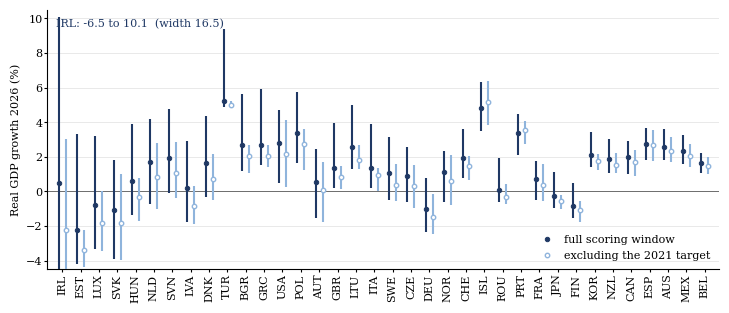


page 7.160 x 3.000 in | scale to \textwidth 1.000 | smallest printed text 8.00 pt (OK)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
"""
Figure 3 — exact 2.5-97.5 percentile ranges for the OWAGDP aggregate of 2026
growth at alpha = 0.5, by country, under both error samples.

Run as a follow-on CELL after the 04 enumeration cell: `full` and `ex21` are
already in memory. If the runtime restarted, it reads the two CSVs instead.

Saved WITHOUT bbox_inches="tight" so the page is exactly 7.16 in, the IEEE
two-column text width. LaTeX then places it at scale 1.000 and the 8 pt labels
print at 8 pt. With a tight bbox the page comes out wider than figsize, LaTeX
shrinks it, and the labels fall below the 8 pt minimum.

The off-scale annotation is built from the data, never typed by hand.

WRITES  fig3.pdf   -> \\includegraphics[width=\\textwidth]{fig3.pdf} in figure*
"""
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

A = "0.5"                      # orness level shown
YEAR = 2026                    # forecast year shown
YLO, YHI = -4.5, 10.5          # axis limits; anything outside is annotated
DARK, LIGHT = "#1F3864", "#8FB4DC"

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Nimbus Roman No9 L", "Times New Roman", "DejaVu Serif"],
    "font.size": 8, "axes.labelsize": 8, "xtick.labelsize": 8,
    "ytick.labelsize": 8, "legend.fontsize": 8,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

try:
    ff, xx = full, ex21
    print("using the DataFrames from the previous cell")
except NameError:
    ff = pd.read_csv("uncertainty_full.csv")
    xx = pd.read_csv("uncertainty_excl2021.csv")
    print("read uncertainty_full.csv and uncertainty_excl2021.csv")

cols = ["iso", f"lo_{A}", f"hi_{A}", f"med_{A}", f"width_{A}"]
d = (ff[ff.year == YEAR][cols]
     .merge(xx[xx.year == YEAR][cols], on="iso", suffixes=("_f", "_x"))
     .sort_values(f"width_{A}_f", ascending=False)
     .reset_index(drop=True))
print(f"{len(d)} economies | widest {d.iloc[0]['iso']} "
      f"{d.iloc[0][f'width_{A}_f']:.3f} | narrowest {d.iloc[-1]['iso']} "
      f"{d.iloc[-1][f'width_{A}_f']:.3f}")

fig, ax = plt.subplots(figsize=(7.16, 3.0))
i, off = np.arange(len(d)), 0.19
ax.grid(axis="y", color="0.88", lw=0.5, zorder=0)
ax.set_axisbelow(True)
ax.axhline(0, color="0.35", lw=0.6, zorder=1)

ax.vlines(i - off, d[f"lo_{A}_f"], d[f"hi_{A}_f"], color=DARK,  lw=1.5, zorder=3)
ax.vlines(i + off, d[f"lo_{A}_x"], d[f"hi_{A}_x"], color=LIGHT, lw=1.5, zorder=3)
ax.plot(i - off, d[f"med_{A}_f"], "o", ms=3.2, mfc=DARK, mec=DARK, mew=0.7,
        lw=0, zorder=4, label="full scoring window")
ax.plot(i + off, d[f"med_{A}_x"], "o", ms=3.2, mfc="white", mec=LIGHT, mew=1.0,
        lw=0, zorder=4, label="excluding the 2021 target")

ax.set_xlim(-0.8, len(d) - 0.2)
ax.set_ylim(YLO, YHI)
ax.set_xticks(i)
ax.set_xticklabels(d["iso"], rotation=90)
ax.set_yticks(np.arange(-4, 11, 2))
ax.set_ylabel(f"Real GDP growth {YEAR} (%)")
ax.tick_params(length=2, pad=1.5)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)

notes = []
for _, r in d.iterrows():                 # iterrows: column names contain dots
    lo, hi, w = r[f"lo_{A}_f"], r[f"hi_{A}_f"], r[f"width_{A}_f"]
    if lo < YLO or hi > YHI:
        notes.append(f"{r['iso']}: {lo:.1f} to {hi:.1f}  (width {w:.1f})")
if notes:
    ax.text(0.012, 0.965, "\n".join(notes), transform=ax.transAxes,
            va="top", ha="left", fontsize=8, color=DARK)
print("off-scale, annotated:", notes if notes else "none")

ax.legend(loc="lower right", frameon=False, handlelength=1.4, borderaxespad=0.4)
fig.tight_layout(pad=0.3)
fig.savefig("fig3.pdf")                   # no bbox_inches -- page == figsize
plt.show()

w_in, h_in = fig.get_size_inches()
scale = 7.16 / w_in
print(f"\npage {w_in:.3f} x {h_in:.3f} in | scale to \\textwidth {scale:.3f} "
      f"| smallest printed text {8 * scale:.2f} pt "
      f"({'OK' if 8 * scale >= 7.99 else 'TOO SMALL'})")

if IN_COLAB:
    files.download("fig3.pdf")